In [1]:
import os 
import pandas as pd

import sys
sys.path.append('../src/utils/')

from utils import read_df

In [2]:
#TASK = "arxiv"
#TASK = "novelpy"
TASK = "cell" 

In [3]:
if TASK == "arxiv":
    TARGET_DATA = "../data/arxiv/arxiv_dataset_all_info.csv"
    TARGET_COLUMN = "novelty"
    ID_COLUMN = "id"
    PREFIX = "arxiv_dataset"
elif TASK == "novelpy":
    TARGET_DATA = None
    TARGET_COLUMN = "score"
    ID_COLUMN = "PMID"
    PREFIX = "novelpy_data"    
elif TASK == "cell":
    TARGET_DATA = None
    TARGET_COLUMN = "wangs_novelty"
    ID_COLUMN = "doi" # FIX me: sometimes it is pubmed_id 
    PREFIX = "cell"
else:
    print("UNKNOWN TASK")

In [4]:
if TARGET_DATA is not None:
    df = pd.read_csv(TARGET_DATA)
    df_target = df[[ID_COLUMN, TARGET_COLUMN]].set_index(ID_COLUMN)
else:
    df_target = None

In [5]:
df_results = []

for filename in os.listdir("../results/"):
    if not filename.startswith(PREFIX):
        continue
    filepath = os.path.join("../results", filename)
    df = read_df(filepath, index_col=0)
    if df.index.name != ID_COLUMN:
        try:
            df = df.groupby(ID_COLUMN).mean()
        except:
            df = df.groupby("pubmed_id").mean()
    filename2 = ".".join(filename.split(".")[:-1])
    df.columns = [f"{filename2[len(PREFIX)+1:-len('_result')]}_score"]
    df_results.append(df)

In [6]:
if df_target is not None:
    df_result = df_target
    start = 0
else:
    df_result = df_results[0]
    start = 1
for df in df_results[start:]:
    df_result = df_result.join(df, how="left")

In [7]:

df_result 

,citations_score,dindex_score,specter2_LOF_n=20_score,wangs_novelty_score,specter2_IF_score
pubmed_id,,,,,
11163236,498.0,0.006631,1.077553,NaN,0.437773
11163237,201.0,-0.008774,1.034555,NaN,0.443174
11163238,479.0,-0.004617,1.035348,NaN,0.428210
11163239,440.0,-0.003654,1.028312,NaN,0.425670
11163240,240.0,-0.013518,1.033731,NaN,0.451961
...,...,...,...,...,...
34942095,0.0,0.001908,1.174992,0.000000,0.488622
34942096,6.0,NaN,1.032870,0.389476,0.440969
34942097,0.0,NaN,1.006485,0.202206,0.418639


array([[<Axes: title={'center': 'citations_score'}>,
        <Axes: title={'center': 'dindex_score'}>],
       [<Axes: title={'center': 'specter2_LOF_n=20_score'}>,
        <Axes: title={'center': 'wangs_novelty_score'}>],
       [<Axes: title={'center': 'specter2_IF_score'}>, <Axes: >]],
      dtype=object)

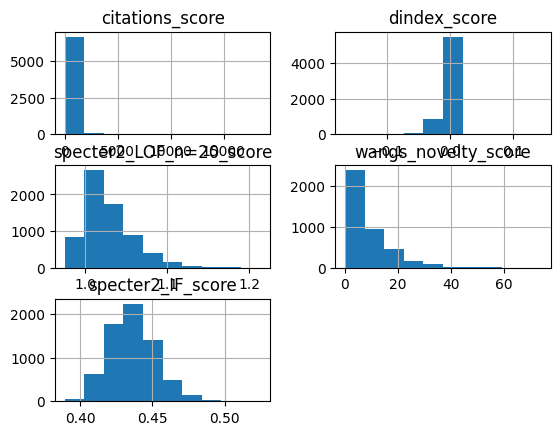

In [8]:
df_result.hist()

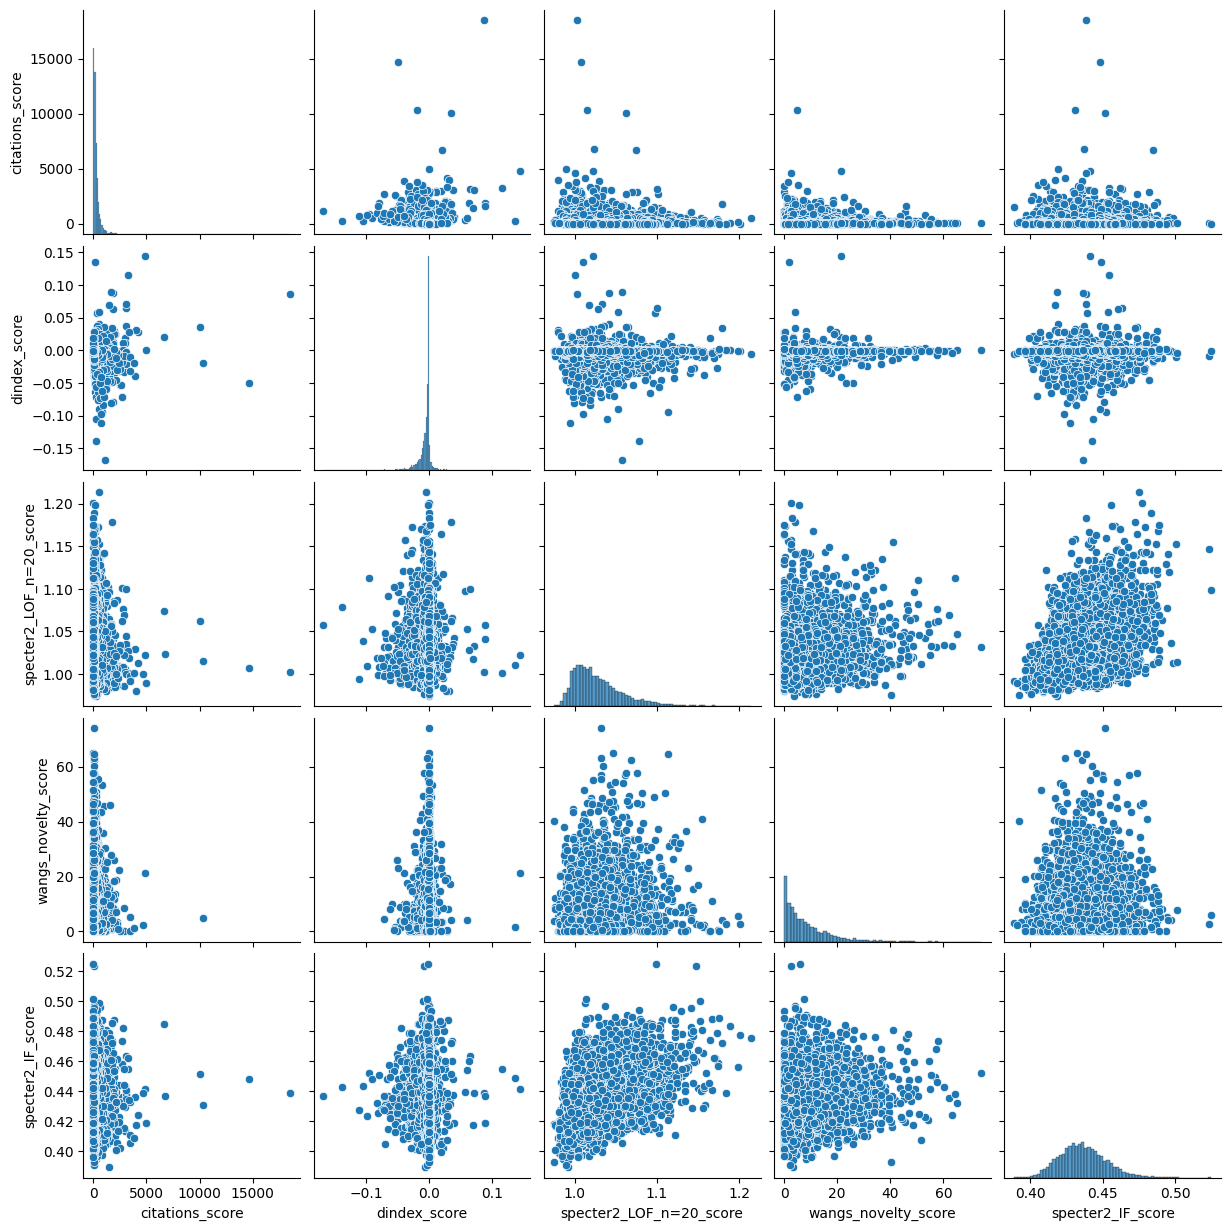

In [9]:
import seaborn as sns
sns.pairplot(df_result)

In [10]:
df_result.corr()

,citations_score,dindex_score,specter2_LOF_n=20_score,wangs_novelty_score,specter2_IF_score
citations_score,1.000000,-0.043593,-0.020271,0.009775,0.023753
dindex_score,-0.043593,1.000000,0.012572,0.099854,-0.005680
specter2_LOF_n=20_score,-0.020271,0.012572,1.000000,0.192449,0.414305
wangs_novelty_score,0.009775,0.099854,0.192449,1.000000,0.118450
specter2_IF_score,0.023753,-0.005680,0.414305,0.118450,1.000000


In [11]:
df_result.corr(method="spearman")

,citations_score,dindex_score,specter2_LOF_n=20_score,wangs_novelty_score,specter2_IF_score
citations_score,1.000000,-0.355661,0.006846,0.068251,0.037103
dindex_score,-0.355661,1.000000,0.023770,0.192891,-0.035863
specter2_LOF_n=20_score,0.006846,0.023770,1.000000,0.202120,0.393310
wangs_novelty_score,0.068251,0.192891,0.202120,1.000000,0.129113
specter2_IF_score,0.037103,-0.035863,0.393310,0.129113,1.000000
